# Deep dive in Mileage_km

In deze file zullen we de tests uitvoeren om ``mileage_km`` te optimalizeren. In deze files worden dus testen uitgevoerd om die code te gebruiken om het hoofdprogramma

Een groot deel van de error komt door ``mileage_km``. Deze kolom is een groot deel dat veel te grote getallen hebben. Dit trekt het gemiddelde serieus omhoog wat zorgt voor heel slechte data. We zullen proberen te zien dat we dit kunnen fixen aan de hand door het linken met de andere parameters.


Aangezien er zoveel hoge getallen zijn zullen we eerts is een bare minimum van 250 000 km pakken en zien hoeveel er boven dat getal zijn

In [58]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# read csv file
dft = pd.read_csv('../csv/new_train_data/train_CarBreakDown.csv')
dft
high_mileage_count = (dft['mileage_km'] > 250_000).sum()
print(f"Number of vehicles with mileage above 20 000 km: {high_mileage_count}")


Number of vehicles with mileage above 20 000 km: 28


**wat zien we**

zoals hierboven zichtbaar zijn er record die boven de 250 000 km zijn, maar wat is de rede hiervoor. Wij denken dat er de mogelijkheid was dat de komma's bij deze getallen verkeerd zijn ingevuld. Hoe gaan we dit kunnen controleren? We zullen beginnnen met eerst de max en min te laten berekenen

In [59]:
# Laat de 10 hoogste mileage voertuigen zien, maar alleen met de gewenste kolommen
top_10_mileage = dft.sort_values(by='mileage_km', ascending=False).head(10)
print(top_10_mileage[['id', 'vehicle_brand', 'vehicle_age_years', 'mileage_km']])

       id vehicle_brand  vehicle_age_years     mileage_km
645  1328    Volkswagen               11.0  324741.253797
113  1448          Ford               20.0  323339.621210
502   550       Renault                6.0  316101.764568
65   1180        Toyota                7.0  308279.894313
255   926          Ford                3.0  304287.739613
601   339           Kia               20.0  299460.585480
106   457          Ford                4.0  284282.342003
660  1057           Kia               20.0  282085.208418
484   453        Toyota                3.0  280805.031039
205  1467       Hyundai                3.0  279238.975395


hierboven zien we dat er nog steeds wat files zijn met veel kilometers. We zullen een boxplot gebruiken om te kijken als er de mogelijkeheid is dat er in deze data een typfout staat of dat de data niet kan gebruikt worden.

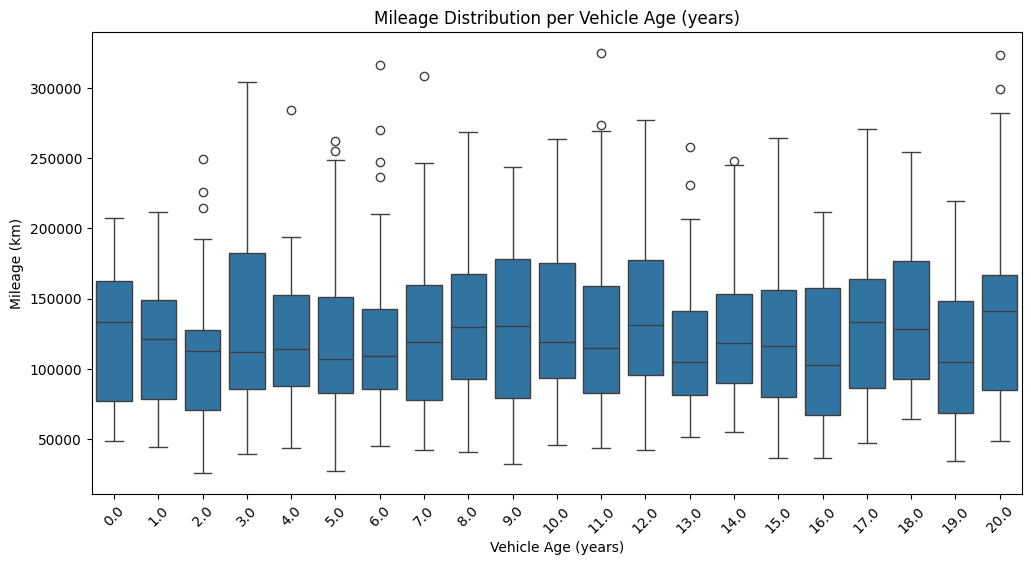

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='vehicle_age_years', y='mileage_km', data=dft)
plt.title("Mileage Distribution per Vehicle Age (years)")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Mileage (km)")
plt.xticks(rotation=45)  # optioneel, draait labels voor betere leesbaarheid
plt.show()

De grafiek toont de verdeling van de kilometerstand per leeftijd van voertuigen. Over het algemeen zien we dat de mediaan van de kilometerstand toeneemt naarmate voertuigen ouder worden, wat logisch is omdat oudere voertuigen meer tijd hebben gehad om kilometers te rijden. Bij jonge voertuigen, van 0 tot 3 jaar, is de spreiding klein, terwijl bij oudere voertuigen de variatie veel groter is. Dit betekent dat sommige oudere voertuigen veel kilometers hebben gereden, terwijl andere relatief weinig kilometers hebben.

Opvallend is echter dat voertuigen van 0 tot 3 jaar soms extreem hoge kilometerstanden hebben, wat onrealistisch lijkt. Dit duidt mogelijk op foutieve data of uitzonderlijke gevallen zoals lease- of demo-auto’s. Hierdoor is het moeilijk om betrouwbare conclusies te trekken over deze jonge voertuigen.

Verder zijn er enkele uitschieters te zien, vooral bij voertuigen van 6 tot 12 jaar, met extreem hoge kilometerstanden van meer dan 300 000 km. Deze uitschieters kunnen wijzen op intensief gebruikte voertuigen, zoals leaseauto’s of taxi’s. Ze laten zien dat leeftijd alleen niet alles zegt over de gebruikstoestand van een voertuig. Ook valt op dat de mediaan soms niet helemaal lineair stijgt, waardoor er kleine onregelmatigheden zijn in de verdeling.

Als groep vonden we het lastig om duidelijke conclusies te trekken uit deze grafiek. Er is veel variatie tussen voertuigen van dezelfde leeftijd en de uitschieters maken het moeilijk om één eenduidige conclusie te geven. Hoewel het algemene patroon logisch lijkt, kwamen we er niet volledig uit welke factoren precies het verschil in kilometerstanden veroorzaken.
